<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/datasets/Social_Network_Ads.csv')

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from mlxtend.plotting import plot_decision_regions

In [6]:
x=df.drop(['User ID','Gender','Purchased'],axis=1)
y=df['Purchased']

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
dt=DecisionTreeClassifier(max_depth=3)
dt.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=3)

In [29]:
dt_entropy = DecisionTreeClassifier(criterion='entropy',max_depth=3)
dt_entropy.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

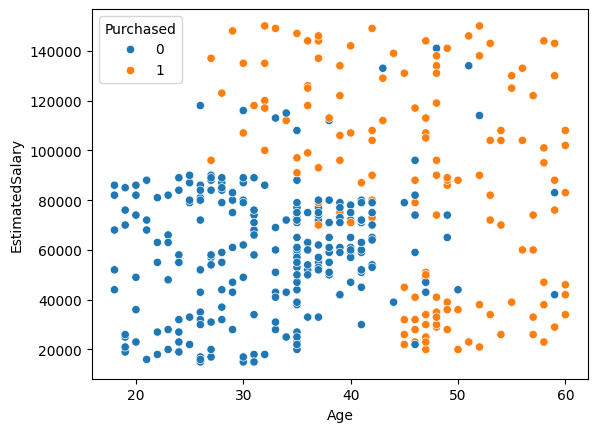

In [9]:
sns.scatterplot(x='Age',y='EstimatedSalary',data=df,hue='Purchased')

In [28]:
dt.score(x_test,y_test)

0.9125

In [30]:
dt_entropy.score(x_test,y_test)

0.9125

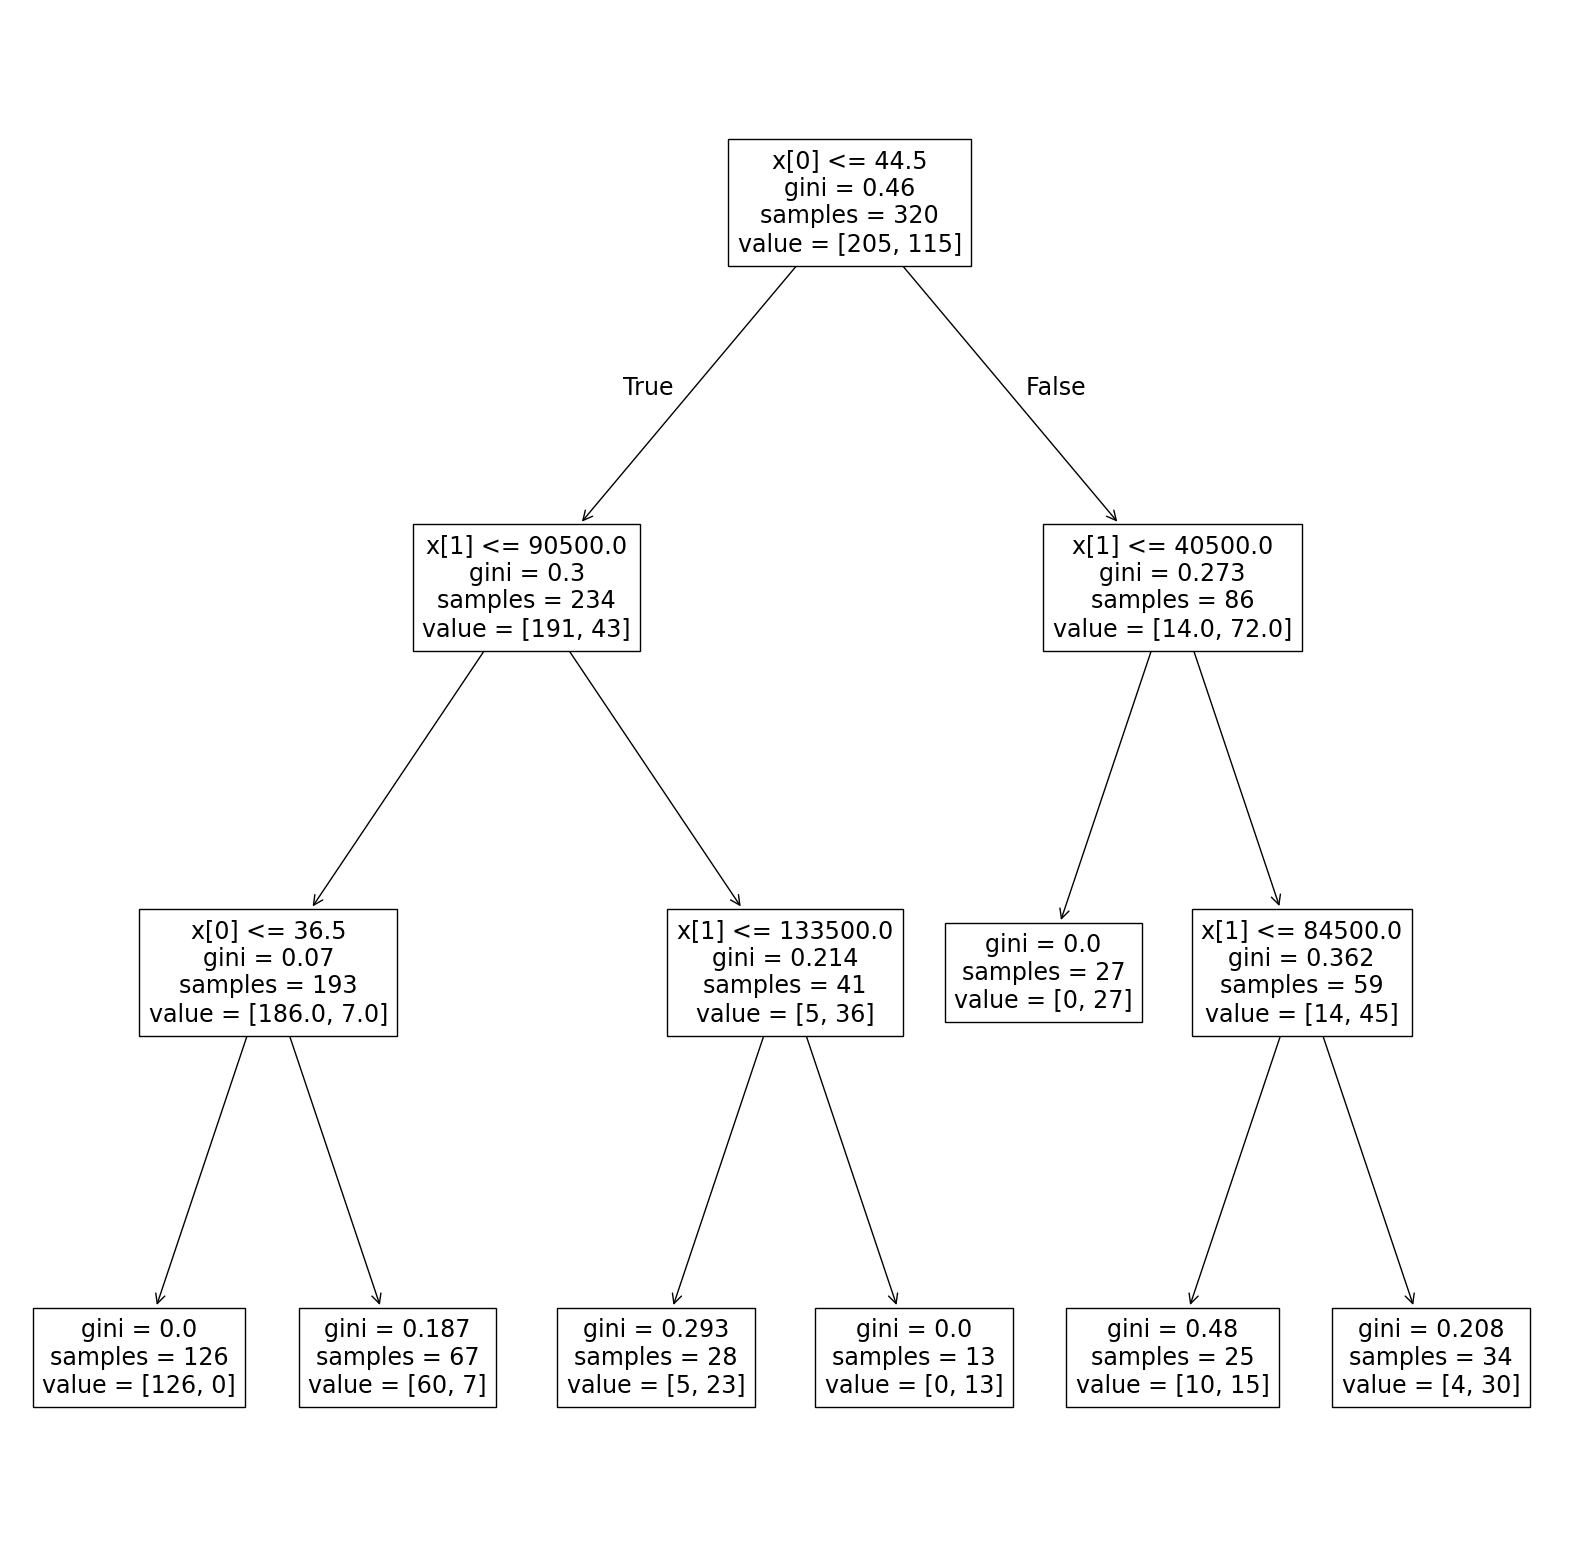

In [31]:
plt.figure(figsize=(20,20))
plot_tree(dt)
plt.show()

<Axes: >

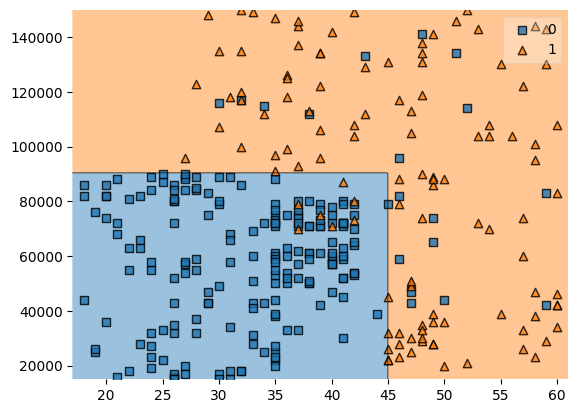

In [32]:
plot_decision_regions(x_train.to_numpy(),y_train.to_numpy(),clf=dt)

In [24]:
for i in range(1,20):
  dt1=DecisionTreeClassifier(max_depth=i)
  dt1.fit(x_train,y_train)
  print(dt1.score(x_test,y_test),dt1.score(x_train,y_train),i)

0.9 0.821875 1
0.9125 0.91875 2
0.9125 0.91875 3
0.9125 0.93125 4
0.9 0.934375 5
0.8625 0.95 6
0.85 0.96875 7
0.85 0.975 8
0.85 0.98125 9
0.85 0.984375 10
0.8375 0.990625 11
0.8375 0.990625 12
0.8375 0.99375 13
0.8375 0.996875 14
0.8375 0.996875 15
0.8375 0.996875 16
0.8375 0.996875 17
0.8375 0.996875 18
0.8375 0.996875 19


In [33]:
dataset=pd.read_csv('/content/drive/MyDrive/datasets/Breast_Cancer_Wisconsin_Dataset.csv')

In [65]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import confusion_matrix,recall_score,f1_score,accuracy_score,precision_score


In [34]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [36]:
dataset['Unnamed: 32'].unique(),dataset['Unnamed: 32'].value_counts()

(array([nan]), Series([], Name: count, dtype: int64))

In [37]:
dataset['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [43]:
encoder=LabelEncoder()
dataset['diagnosis']=encoder.fit_transform(dataset['diagnosis'])

In [44]:
dataset['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [45]:
x=dataset.drop(['diagnosis','Unnamed: 32','id'],axis=1)
y=dataset['diagnosis']

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
doctor_tree=DecisionTreeClassifier(max_depth=3)
doctor_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [55]:
doctor_tree.score(x_test,y_test)

0.9473684210526315

In [49]:
doctor_tree.score(x_train,y_train)

0.978021978021978

In [56]:
for i in range(1,20):
  doc_tree=DecisionTreeClassifier(max_depth=i)
  doc_tree.fit(x_train,y_train)
  print(doc_tree.score(x_test,y_test)*100,doc_tree.score(x_train,y_train)*100,i)

89.47368421052632 92.08791208791209 1
92.98245614035088 92.96703296703296 2
94.73684210526315 97.8021978021978 3
93.85964912280701 99.56043956043956 4
94.73684210526315 99.56043956043956 5
93.85964912280701 99.78021978021978 6
92.98245614035088 100.0 7
94.73684210526315 100.0 8
93.85964912280701 100.0 9
93.85964912280701 100.0 10
94.73684210526315 100.0 11
92.98245614035088 100.0 12
94.73684210526315 100.0 13
93.85964912280701 100.0 14
93.85964912280701 100.0 15
94.73684210526315 100.0 16
94.73684210526315 100.0 17
94.73684210526315 100.0 18
94.73684210526315 100.0 19


In [58]:
cm=confusion_matrix(y_test,doctor_tree.predict(x_test))

<Axes: >

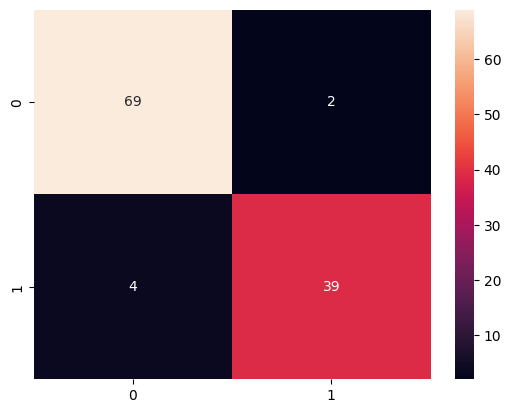

In [60]:
sns.heatmap(cm,annot=True)

In [66]:
print(f"Accuracy Score: {accuracy_score(y_test,doctor_tree.predict(x_test))}")
print(f"Recall Score: {recall_score(y_test,doctor_tree.predict(x_test))}")
print(f"f1_score: {f1_score(y_test,doctor_tree.predict(x_test))}")
print(f"Precision Score: {precision_score(y_test,doctor_tree.predict(x_test))}")

Accuracy Score: 0.9473684210526315
Recall Score: 0.9069767441860465
f1_score: 0.9285714285714286
Precision Score: 0.9512195121951219
